In [1]:
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score
import joblib
import torch
import torch.nn as nn
from torchvision.transforms import Resize, ToTensor, Compose, Normalize, transforms
from torchvision.models import resnet18, resnet34, resnet50, resnet101, densenet121, densenet169, densenet201, vgg11, vgg13, vgg16, vgg19, efficientnet_b0, efficientnet_b1, efficientnet_b2, efficientnet_b5, efficientnet_b6, efficientnet_b7, inception_v3, googlenet, mobilenet_v3_small, mobilenet_v2

from tqdm import tqdm
from torchvision import transforms
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from os import listdir
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.layers import Reshape
from keras.layers import Input, Dense, concatenate
from keras.models import Model
from collections import defaultdict
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from torchvision.models import mobilenet_v3_large
from sklearn.metrics import precision_score, recall_score
import seaborn as sns
import tensorflow as tf

In [2]:
import torchvision.models as models

all_models = dir(models)
model_names = [model for model in all_models if callable(getattr(models, model))]
print("Available models in torchvision.models:")
#for name in model_names:
#    print(name)

Available models in torchvision.models:


In [5]:
data = pd.read_csv("/kaggle/input/brain-tumor-csv/Brain Tumor.csv")
data.head()

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


In [6]:
images = data.Image
classes = data.Class
image_label_dict = data.set_index('Image')['Class'].to_dict()
#print(image_label_dict)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [8]:
def preprocess_image(image_path):
  image = Image.open(image_path).convert('RGB')
  transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      #transforms.Normalize(mean=[0.5], std=[0.5])
  ])
  image = transform(image)
  image = image.unsqueeze(0)
  return image.to(device)
def extract_features(image, model):
  with torch.no_grad():
    feature = model(image).squeeze().cpu().numpy()
  return feature
def extract_features_from_image(image_path, model):
  image = preprocess_image(image_path)
  features = extract_features(image, model)
  return features
def preprocess_image_pca(image_path):
    image = Image.open(image_path).convert('RGB') 
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    image = transform(image)
    image = image.numpy().flatten()
    return image

**ResNet 18**

In [9]:
resnet18_model = resnet18(pretrained=True)
resnet18_model = nn.Sequential(*list(resnet18_model.children())[:-1])
resnet18_model = resnet18_model.to(device)
resnet18_model.eval()

dir_list = '/kaggle/input/reloaded-crop/Crop/'
X_resnet = []
X_pca_orig = []
Y = []
filename_list = []

for filename in tqdm(listdir(dir_list)):
  if filename.endswith('.jpg'):
    #print(filename)
    filename_list.append(filename)
    path = dir_list + filename
    label = image_label_dict.get(filename.split('.')[0], None)
    if label is not None:
      features = extract_features_from_image(path, resnet18_model)
      X_resnet.append(features)
      feature_pca = preprocess_image_pca(path)
      X_pca_orig.append(feature_pca)
      Y.append(label)
X_resnet = np.array(X_resnet)
X_pca_orig = np.array(X_pca_orig)
Y = np.array(Y)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]
100%|██████████| 3762/3762 [04:06<00:00, 15.28it/s]


In [10]:
print(X_resnet[0].shape)
print(X_pca_orig[0].shape)

(512,)
(150528,)


In [11]:
n_components = 0.95
pca_model = PCA(n_components=n_components, random_state=42)
X_pca = pca_model.fit_transform(X_pca_orig)
print(X_pca[0].shape)
X_pca = np.hstack((X_resnet, X_pca))
print(X_pca[0].shape)

(378,)
(890,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size=0.5, random_state=42)
print(X_train.shape)

(1881, 890)


In [13]:
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_test_pred = svm_model.predict(X_test)

print("Test F1 Score:", f1_score(y_test, y_test_pred))
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred, digits=4))

Test F1 Score: 0.9163154726068633
Accuracy: 0.9261031366294524
Precision: 0.9257907542579076
Recall: 0.9070321811680572
Classification Report:
               precision    recall  f1-score   support

           0     0.9263    0.9415    0.9338      1042
           1     0.9258    0.9070    0.9163       839

    accuracy                         0.9261      1881
   macro avg     0.9261    0.9242    0.9251      1881
weighted avg     0.9261    0.9261    0.9260      1881



In [14]:
mobilenet_v3_large_model = models.mobilenet_v3_large(pretrained=True) 
mobilenet_v3_large_model = nn.Sequential(*list(mobilenet_v3_large_model.children())[:-1])  
mobilenet_v3_large_model = mobilenet_v3_large_model.to(device)
mobilenet_v3_large_model.eval()

# Define directories and arrays for features
dir_list = '/kaggle/input/reloaded-crop/Crop/'
X_mobilenet_v3_large = []
X_pca_orig = []
Y = []
filename_list = []

for filename in tqdm(listdir(dir_list)):
    if filename.endswith('.jpg'):
        filename_list.append(filename)
        path = dir_list + filename
        label = image_label_dict.get(filename.split('.')[0], None)
        
        if label is not None:
            features = extract_features_from_image(path, mobilenet_v3_large_model)
            features = features.flatten()  
            X_mobilenet_v3_large.append(features)
            feature_pca = preprocess_image_pca(path)
            X_pca_orig.append(feature_pca)
            Y.append(label)

X_resnet = np.array(X_mobilenet_v3_large)
X_pca_orig = np.array(X_pca_orig)
Y = np.array(Y)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 192MB/s]
100%|██████████| 3762/3762 [01:51<00:00, 33.68it/s]


In [15]:
print(X_resnet[0].shape)
print(X_pca_orig[0].shape)

(960,)
(150528,)


In [16]:
n_components = 0.95
pca_model = PCA(n_components=n_components, random_state=42)
X_pca = pca_model.fit_transform(X_pca_orig)
print(X_pca[0].shape)
X_pca = np.hstack((X_resnet, X_pca))
print(X_pca[0].shape)

(378,)
(1338,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size=0.5, random_state=42)
print(X_train.shape)

(1881, 1338)


In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_test_pred = svm_model.predict(X_test)

print("Test F1 Score:", f1_score(y_test, y_test_pred))
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred, digits=4))

Test F1 Score: 0.9572649572649572
Accuracy: 0.9627857522594365
Precision: 0.981226533166458
Recall: 0.9344457687723481
Classification Report:
               precision    recall  f1-score   support

           0     0.9492    0.9856    0.9670      1042
           1     0.9812    0.9344    0.9573       839

    accuracy                         0.9628      1881
   macro avg     0.9652    0.9600    0.9622      1881
weighted avg     0.9635    0.9628    0.9627      1881



**ResNet18 + PCA + Model 1, 2, 3**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size=0.5, random_state=42)

In [18]:
print(X_train.shape)

(1881, 1338)


In [18]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [19]:
def create_cnn_model(input_shape, num_filters):
  model = Sequential()
  model = Sequential()
  model.add(Reshape((input_shape[1], 1), input_shape=input_shape[1:]))
  model.add(Conv1D(filters=num_filters, kernel_size=3, activation='relu', input_shape=(500, 1)))
  model.add(MaxPooling1D(pool_size=2))
  model.add(Conv1D(filters=num_filters * 2, kernel_size=3, activation='relu'))
  model.add(MaxPooling1D(pool_size=2))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

model1 = create_cnn_model(X_train.shape, 32)
model2 = create_cnn_model(X_train.shape, 64)
model3 = create_cnn_model(X_train.shape, 48)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

y_train = y_train.astype('float32')
y_val = y_val.astype('float32')
y_test = y_test.astype('float32')

model1.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_val, y_val))
model2.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_val, y_val))
model3.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_val, y_val))

loss, accuracy = model1.evaluate(X_test, y_test)
print(f'Accuracy1: {accuracy*100:.2f}%')

loss, accuracy = model2.evaluate(X_test, y_test)
print(f'Accuracy2: {accuracy*100:.2f}%')

loss, accuracy = model3.evaluate(X_test, y_test)
print(f'Accuracy3: {accuracy*100:.2f}%')

/opt/conda/lib/python3.10/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.6714 - loss: 0.8172 - val_accuracy: 0.9435 - val_loss: 0.1734
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9513 - loss: 0.1469 - val_accuracy: 0.9611 - val_loss: 0.1320
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9835 - loss: 0.0608 - val_accuracy: 0.9576 - val_loss: 0.1407
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9968 - loss: 0.0246 - val_accuracy: 0.9470 - val_loss: 0.1538
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 0.9541 - val_loss: 0.1517
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.9611 - val_loss: 0.1466
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9505 - val_loss: 0.1570
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9576 - v

In [20]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 1338, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1336, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 668, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 666, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 333, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,364,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,111,301 (15.68 MB)

 Trainable params: 1,370,433 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,740,868 (10.46 MB)

In [21]:
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 1338, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1336, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 668, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 666, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 333, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 42624)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,728,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,259,077 (31.51 MB)

 Trainable params: 2,753,025 (10.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,506,052 (21.00 MB)

In [22]:
model3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 1338, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1336, 48)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 668, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 666, 96)        │        13,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 333, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 31968)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,046,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,180,581 (23.58 MB)

 Trainable params: 2,060,193 (7.86 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,120,388 (15.72 MB)

In [21]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

thresholds = np.arange(0, 1.01, 0.01) 
best_threshold = 0.0
best_f1 = 0.0

for threshold in thresholds:
  y_pred_classes = (y_pred1 >= threshold).astype(int)
  f1 = f1_score(y_test, y_pred_classes)
  if f1 > best_f1:
    best_f1 = f1
    best_threshold = threshold
print(f'F1-score1: {best_f1:.4f}')
y_pred1 = (y_pred1 > best_threshold).astype(int)

best_threshold = 0.0
best_f1 = 0.0

for threshold in thresholds:
  y_pred_classes = (y_pred2 >= threshold).astype(int)
  f1 = f1_score(y_test, y_pred_classes)
  if f1 > best_f1:
    best_f1 = f1
    best_threshold = threshold
print(f'F1-score2: {best_f1:.4f}')
y_pred2 = (y_pred2 > best_threshold).astype(int)

best_threshold = 0.0
best_f1 = 0.0

for threshold in thresholds:
  y_pred_classes = (y_pred3 >= threshold).astype(int)
  f1 = f1_score(y_test, y_pred_classes)
  if f1 > best_f1:
    best_f1 = f1
    best_threshold = threshold
print(f'F1-score3: {best_f1:.4f}')
y_pred3 = (y_pred3 > best_threshold).astype(int)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
F1-score1: 0.9485
F1-score2: 0.9492
F1-score3: 0.9524


In [22]:
def print_metrics(y_test, y_pred, model_number):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Model {model_number} - Metrics:")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Confusion Matrix - Model {model_number}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Gompertz function

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
(1881, 2)
(1881, 2)
(1881, 2)
Model Ensemble with Gompertz - Metrics:
Accuracy: 95.37%
Precision: 0.9574
Recall: 0.9380
F1 Score: 0.9476

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      1042
         1.0       0.96      0.94      0.95       839

    accuracy                           0.95      1881
   macro avg       0.95      0.95      0.95      1881
weighted avg       0.95      0.95      0.95      1881



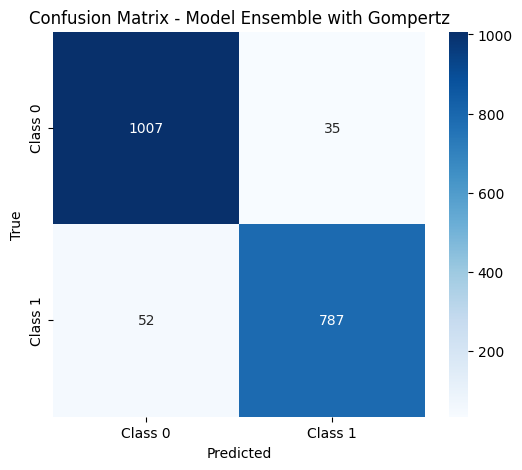

In [24]:
import math
def fuzzy_rank(CF, top):
    R_L = np.zeros(CF.shape)
    for i in range(CF.shape[0]):
        for j in range(CF.shape[1]):
            for k in range(CF.shape[2]):
                R_L[i][j][k] = 1 - math.exp(-math.exp(-2.0 * CF[i][j][k])) 
    
    K_L = 0.632 * np.ones(shape=R_L.shape) 
    for i in range(R_L.shape[0]):
        for sample in range(R_L.shape[1]):
            for k in range(top):
                a = R_L[i][sample]
                idx = np.where(a == np.partition(a, k)[k])
                K_L[i][sample][idx] = R_L[i][sample][idx]

    return K_L

def CFS_func(CF, K_L):
    H = CF.shape[0]  # Số lượng bộ phân loại
    for f in range(CF.shape[0]):
        for i in range(CF.shape[1]):
            idx = np.where(K_L[f][i] == 0.632)
            CF[f][i][idx] = 0
    CFS = 1 - np.sum(CF, axis=0) / H
    return CFS

def Gompertz(top=2, *argv):
    L = len(argv)  # Số lượng bộ phân loại
    num_classes = argv[0].shape[1]
    CF = np.zeros(shape=(L, argv[0].shape[0], num_classes))

    for i, arg in enumerate(argv):
        CF[i] = arg

    R_L = fuzzy_rank(CF, top) 
    RS = np.sum(R_L, axis=0)
    CFS = CFS_func(CF, R_L)
    FS = RS * CFS

    predictions = np.argmin(FS, axis=1)
    return predictions
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

y_pred1 = np.hstack((1 - y_pred1, y_pred1))  
y_pred2 = np.hstack((1 - y_pred2, y_pred2))
y_pred3 = np.hstack((1 - y_pred3, y_pred3))

print(y_pred1.shape) 
print(y_pred2.shape) 
print(y_pred3.shape)  
final_predictions = Gompertz(2, y_pred1, y_pred2, y_pred3)
print_metrics(y_test, final_predictions, 'Ensemble with Gompertz')

# Mitscherlich fuzzy rank

In [25]:
def fuzzy_rank(CF, top):
    R_L = np.zeros(CF.shape)
    for i in range(CF.shape[0]):
        for j in range(CF.shape[1]):
            for k in range(CF.shape[2]):
                R_L[i][j][k] = (2 - 1 * 2 ** CF[i][j][k])

    K_L = 1 * np.ones(shape=R_L.shape)
    for i in range(R_L.shape[0]):
        for sample in range(R_L.shape[1]):
            for k in range(top - 1):
                a = R_L[i][sample]
                idx = np.where(a == np.partition(a, k)[k])
                K_L[i][sample][idx] = R_L[i][sample][idx]

    return K_L

def CFS_func(CF, K_L):
    H = CF.shape[0]
    for f in range(CF.shape[0]):
        for i in range(CF.shape[1]):
            idx = np.where(K_L[f][i] == 1)
            CF[f][i][idx] = 0
    CFS = 1 - np.sum(CF, axis=0) / H
    return CFS

def Mitcherlich(top=2, *argv):
    L = len(argv)
    num_classes = argv[0].shape[1]
    CF = np.zeros(shape=(L, argv[0].shape[0], num_classes))

    for i, arg in enumerate(argv):
        CF[i] = arg

    R_L = fuzzy_rank(CF, top)
    RS = np.sum(R_L, axis=0)
    CFS = CFS_func(CF, R_L)
    FS = RS * CFS

    predictions = np.argmin(FS, axis=1) 
    return predictions

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
(1881, 2)
(1881, 2)
(1881, 2)
Model Ensemble Mitscherlich - Metrics:
Accuracy: 95.43%
Precision: 0.9597
Recall: 0.9368
F1 Score: 0.9481

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      1042
         1.0       0.96      0.94      0.95       839

    accuracy                           0.95      1881
   macro avg       0.95      0.95      0.95      1881
weighted avg       0.95      0.95      0.95      1881



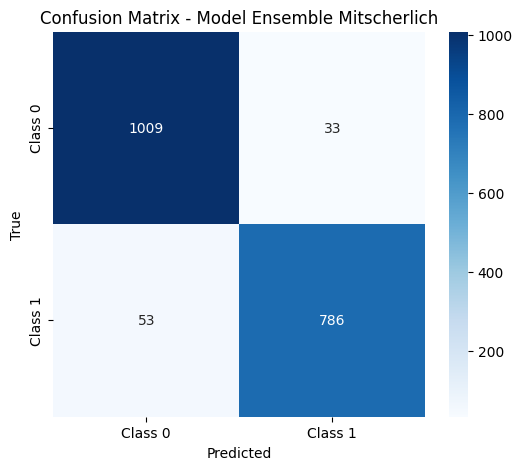

In [32]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

y_pred1 = np.hstack((1 - y_pred1, y_pred1))  
y_pred2 = np.hstack((1 - y_pred2, y_pred2))
y_pred3 = np.hstack((1 - y_pred3, y_pred3))

print(y_pred1.shape) 
print(y_pred2.shape) 
print(y_pred3.shape)  
predictions = Mitcherlich(2, y_pred1, y_pred2, y_pred3)
print_metrics(y_test, predictions, 'Ensemble Mitscherlich')

In [29]:
y_pred1_prob = model1.predict(X_train).flatten()  
y_pred2_prob = model2.predict(X_train).flatten()  
y_pred3_prob = model3.predict(X_train).flatten()  

y_pred_probs_train = np.column_stack((y_pred1_prob, y_pred2_prob, y_pred3_prob))

C_values = [0.1, 0.5, 1, 2, 5, 10, 15, 20, 50]
gamma_values = ['scale', 'auto']

best_f1 = 0
best_params = {}

for C in C_values:
    for gamma in gamma_values:
        ensemble_model_svm = SVC(kernel='rbf', C=C, gamma=gamma, probability=True, random_state=42)
        ensemble_model_svm.fit(y_pred_probs_train, y_train)

        y_pred1_prob_val = model1.predict(X_val).flatten()  
        y_pred2_prob_val = model2.predict(X_val).flatten()  
        y_pred3_prob_val = model3.predict(X_val).flatten()

        y_pred_probs_val = np.column_stack((y_pred1_prob_val, y_pred2_prob_val, y_pred3_prob_val))

        y_pred_ensemble_svm = ensemble_model_svm.predict(y_pred_probs_val)

        f1_ensemble_svm = f1_score(y_val, y_pred_ensemble_svm)

        if f1_ensemble_svm > best_f1:
            best_f1 = f1_ensemble_svm
            best_params = {'C': C, 'gamma': gamma}

print(f"Best Hyperparameters: {best_params}")
print(f"Best F1-score (Ensemble SVM on Validation): {best_f1:.4f}")

ensemble_model_svm = SVC(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'], probability=True, random_state=42)
ensemble_model_svm.fit(y_pred_probs_train, y_train)

y_pred1_prob_test = model1.predict(X_test).flatten() 
y_pred2_prob_test = model2.predict(X_test).flatten()  
y_pred3_prob_test = model3.predict(X_test).flatten()

y_pred_probs_test = np.column_stack((y_pred1_prob_test, y_pred2_prob_test, y_pred3_prob_test))

y_pred_ensemble_svm = ensemble_model_svm.predict(y_pred_probs_test)

f1_ensemble_svm_test = f1_score(y_test, y_pred_ensemble_svm)
accuracy_ensemble_svm_test = accuracy_score(y_test, y_pred_ensemble_svm)
precision_ensemble_svm_test = precision_score(y_test, y_pred_ensemble_svm)
recall_ensemble_svm_test = recall_score(y_test, y_pred_ensemble_svm)

print(f'Ensemble F1-score (SVM on Test Set): {f1_ensemble_svm_test:.4f}')
print(f'Ensemble Accuracy (SVM on Test Set): {accuracy_ensemble_svm_test:.4f}')
print(f'Ensemble Precision (SVM on Test Set): {precision_ensemble_svm_test:.4f}')
print(f'Ensemble Recall (SVM on Test Set): {recall_ensemble_svm_test:.4f}')

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
9/9 ━━

Model Ensemble SVM - Metrics:
Accuracy: 95.37%
Precision: 0.9574
Recall: 0.9380
F1 Score: 0.9476

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      1042
         1.0       0.96      0.94      0.95       839

    accuracy                           0.95      1881
   macro avg       0.95      0.95      0.95      1881
weighted avg       0.95      0.95      0.95      1881



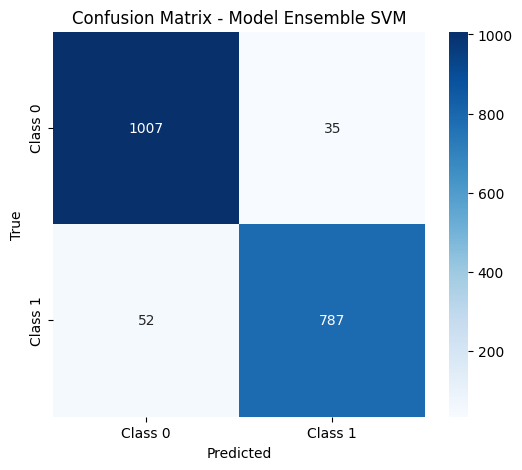

In [30]:
print_metrics(y_test, y_pred_ensemble_svm, 'Ensemble SVM')